In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from config import (
    rng, TRUE_A, TRUE_MU, TRUE_SIG, TRUE_B,
    N_REPS, NOISE_STD_TUNING, ORIENTATIONS
)
from utils import r2_score

In [2]:
# --- TODO 1: Define Gaussian tuning function ---
def gaussian_tuning(theta, A, mu, sigma, b):
    # Standard Gaussian formula: A * exp(-0.5 * ((x - mu)/sigma)^2) + baseline
    return A * np.exp(-0.5 * ((theta - mu) / sigma)**2) + b

In [3]:
# --- TODO 2: Simulate repeated noisy firing rates ---
all_rates = np.zeros((len(ORIENTATIONS), N_REPS))

for idx, theta in enumerate(ORIENTATIONS):
    # Calculate the theoretical "clean" rate
    true_rate = gaussian_tuning(theta, TRUE_A, TRUE_MU, TRUE_SIG, TRUE_B)
    
    # Add Gaussian noise and ensure no negative firing rates
    noisy_rates = rng.normal(true_rate, NOISE_STD_TUNING, size=N_REPS)
    noisy_rates = np.maximum(0, noisy_rates) # Clip at 0
    all_rates[idx] = noisy_rates

mean_rates = np.mean(all_rates, axis=1)
std_rates = np.std(all_rates, axis=1)

In [4]:
# --- TODO 3: Fit Gaussian tuning curve to mean rates ---
p0 = [40, 80, 20, 2] # Initial guess for [A, mu, sigma, b]
popt, pcov = curve_fit(gaussian_tuning, ORIENTATIONS, mean_rates, p0=p0)

A_fit, mu_fit, sig_fit, b_fit = popt

In [5]:
# --- TODO 4: Compute R² ---
fitted_curve = gaussian_tuning(ORIENTATIONS, *popt)
R2 = r2_score(mean_rates, fitted_curve)
print(f"R² : {R2:.4f}")

R² : 0.9965


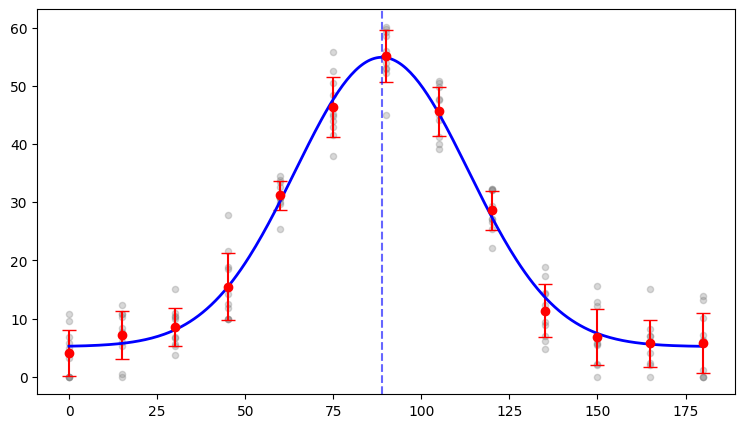

In [6]:
# --- TODO 5: Plotting ---
theta_fine = np.linspace(0, 180, 300)
fit_fine = gaussian_tuning(theta_fine, *popt)

fig, ax = plt.subplots(figsize=(9, 5))

# Scatter individual measurements
for i, theta in enumerate(ORIENTATIONS):
    ax.scatter([theta] * N_REPS, all_rates[i], alpha=0.3, s=20, color='gray',
               label='Individual' if i == 0 else None)

# Add error bars for the mean rates
ax.errorbar(ORIENTATIONS, mean_rates, yerr=std_rates, fmt='o', color='red', 
            capsize=5, label='Mean ± STD')

# Add the smooth fitted Gaussian curve
ax.plot(theta_fine, fit_fine, color='blue', linewidth=2, label='Fitted Gaussian')

# Add vertical dashed line at the preferred orientation (mu)
ax.axvline(x=mu_fit, color='blue', linestyle='--', alpha=0.6, label=f'Peak ({mu_fit:.1f}°)')